In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [20]:
sp500 = pd.read_csv('sp500_clean.csv')
vix   = pd.read_csv('vix_clean.csv')

In [21]:
print(sp500.head())
print(sp500.columns)

        Price              Close  log_return   vol_20d   vol_60d  vol_120d
0      Ticker              ^GSPC         NaN       NaN       NaN       NaN
1        Date                NaN         NaN       NaN       NaN       NaN
2  1993-06-24  446.6199951171875    0.007710  0.005083  0.006238  0.006347
3  1993-06-25  447.6000061035156    0.002192  0.005111  0.006245  0.006345
4  1993-06-28  451.8500061035156    0.009450  0.005460  0.006354  0.006400
Index(['Price', 'Close', 'log_return', 'vol_20d', 'vol_60d', 'vol_120d'], dtype='object')


In [22]:
# -------------------------------
# 2. Rename columns properly
# -------------------------------
sp500.rename(columns={'Price': 'Date'}, inplace=True)
vix.rename(columns={'Price': 'Date'}, inplace=True)

In [23]:
sp500['Date'] = pd.to_datetime(sp500['Date'], format='mixed', errors='coerce')
vix['Date']   = pd.to_datetime(vix['Date'], format='mixed', errors='coerce')

In [24]:
sp500.set_index('Date', inplace=True)
vix.set_index('Date', inplace=True)

In [25]:
print(sp500.head())
print(sp500.columns)


                        Close  log_return   vol_20d   vol_60d  vol_120d
Date                                                                   
NaT                     ^GSPC         NaN       NaN       NaN       NaN
NaT                       NaN         NaN       NaN       NaN       NaN
1993-06-24  446.6199951171875    0.007710  0.005083  0.006238  0.006347
1993-06-25  447.6000061035156    0.002192  0.005111  0.006245  0.006345
1993-06-28  451.8500061035156    0.009450  0.005460  0.006354  0.006400
Index(['Close', 'log_return', 'vol_20d', 'vol_60d', 'vol_120d'], dtype='object')


In [26]:
print(sp500.dtypes)

Close          object
log_return    float64
vol_20d       float64
vol_60d       float64
vol_120d      float64
dtype: object


In [27]:
sp500['Close']=pd.to_numeric(sp500['Close'],errors='coerce')

In [28]:
print(vix.head())
print(vix.columns)

                         Close  log_return
Date                                      
NaT                       ^VIX         NaN
NaT                        NaN         NaN
1993-01-05  13.350000381469727   -0.000749
1993-01-06  13.369999885559082    0.001497
1993-01-07  14.720000267028809    0.096194
Index(['Close', 'log_return'], dtype='object')


In [29]:
# -------------------------------
# 7. Align data PROPERLY
# -------------------------------
data = pd.merge(
    sp500[['log_return']],
    vix[['Close']],
    left_index=True,
    right_index=True,
    how='inner'
)

In [30]:
# Rename columns
data.columns = ['sp500_return', 'vix_close']

data = data.dropna()

print("Clean Data:")
print(data.head())
print("Shape:", data.shape)


Clean Data:
            sp500_return           vix_close
Date                                        
1993-06-24      0.007710               12.25
1993-06-25      0.002192               11.25
1993-06-28      0.009450  11.109999656677246
1993-06-29     -0.002571  11.289999961853027
1993-06-30     -0.000355  11.260000228881836
Shape: (7936, 2)


In [31]:
# -------------------------------
# 8. Feature Engineering
# -------------------------------
def compute_features(returns, vix_close, window=20):
    features = pd.DataFrame(index=returns.index)

    features['rolling_mean']=returns.rolling(window).mean()
    
    ##realized Volatility=Standard Deviation of 20 days*square root(252)
    ##As 252 trading days
    features['realized_vol']=returns.rolling(window).std()*np.sqrt(252)
    
    ##To check how much the data is skewed and tilted towardswhich side.
    features['skewness']=returns.rolling(window).apply(skew, raw=True)


    
    features['kurtosis']=returns.rolling(window).apply(kurtosis, raw=True)
    features['vix_level']=vix_close
    features['vix_change']=vix_close.pct_change()

    implied_vol = vix_close / 100
    features['vix_spread'] = implied_vol - features['realized_vol']

    features['corr_sp500_vix'] = returns.rolling(window).corr(vix_close)

    return features.dropna()


In [32]:
print(data.dtypes)

sp500_return    float64
vix_close        object
dtype: object


In [33]:
data['sp500_return'] = pd.to_numeric(data['sp500_return'], errors='coerce')
data['vix_close']    = pd.to_numeric(data['vix_close'], errors='coerce')

In [34]:
print(data.dtypes)

sp500_return    float64
vix_close       float64
dtype: object


In [35]:
# -------------------------------
# 9. Compute Features
# -------------------------------
features_20 = compute_features(data['sp500_return'], data['vix_close'], 20)

print("\nFeatures:")
print(features_20.head())


Features:
            rolling_mean  realized_vol  skewness  kurtosis  vix_level  \
Date                                                                    
1993-07-22      0.000149      0.091949  0.360993 -0.168377      11.69   
1993-07-23      0.000054      0.090106  0.361060 -0.026061      11.32   
1993-07-26      0.000166      0.091161  0.309674 -0.170904      11.32   
1993-07-27     -0.000401      0.084488  0.428593  0.438424      11.34   
1993-07-28     -0.000390      0.084415  0.424212  0.446069      11.37   

            vix_change  vix_spread  corr_sp500_vix  
Date                                                
1993-07-22   -0.023392    0.024951       -0.056248  
1993-07-23   -0.031651    0.023094       -0.136878  
1993-07-26    0.000000    0.022039       -0.137696  
1993-07-27    0.001767    0.028912       -0.102200  
1993-07-28    0.002645    0.029285       -0.104895  


In [36]:
features_20.to_csv('features_20d.csv', index=True)
print("Saved features_20d.csv")

Saved features_20d.csv


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [38]:
# -------------------------------
# 1. CREATE FEATURES (REQUIRED)
# -------------------------------
window = 60

data['mean_return'] = data['sp500_return'].rolling(window).mean()
data['volatility']  = data['sp500_return'].rolling(window).std() * np.sqrt(252)
data['skewness']    = data['sp500_return'].rolling(window).skew()
data['kurt']        = data['sp500_return'].rolling(window).kurt()

# Sharpe Ratio
data['sharpe'] = data['mean_return'] / data['volatility']

# VIX Spread
data['vix_spread'] = (data['vix_close'] / 100) - data['volatility']

# Correlation
data['sp500_vix_corr'] = data['sp500_return'].rolling(window).corr(data['vix_close'])

# Drop NaNs after rolling
data = data.dropna()



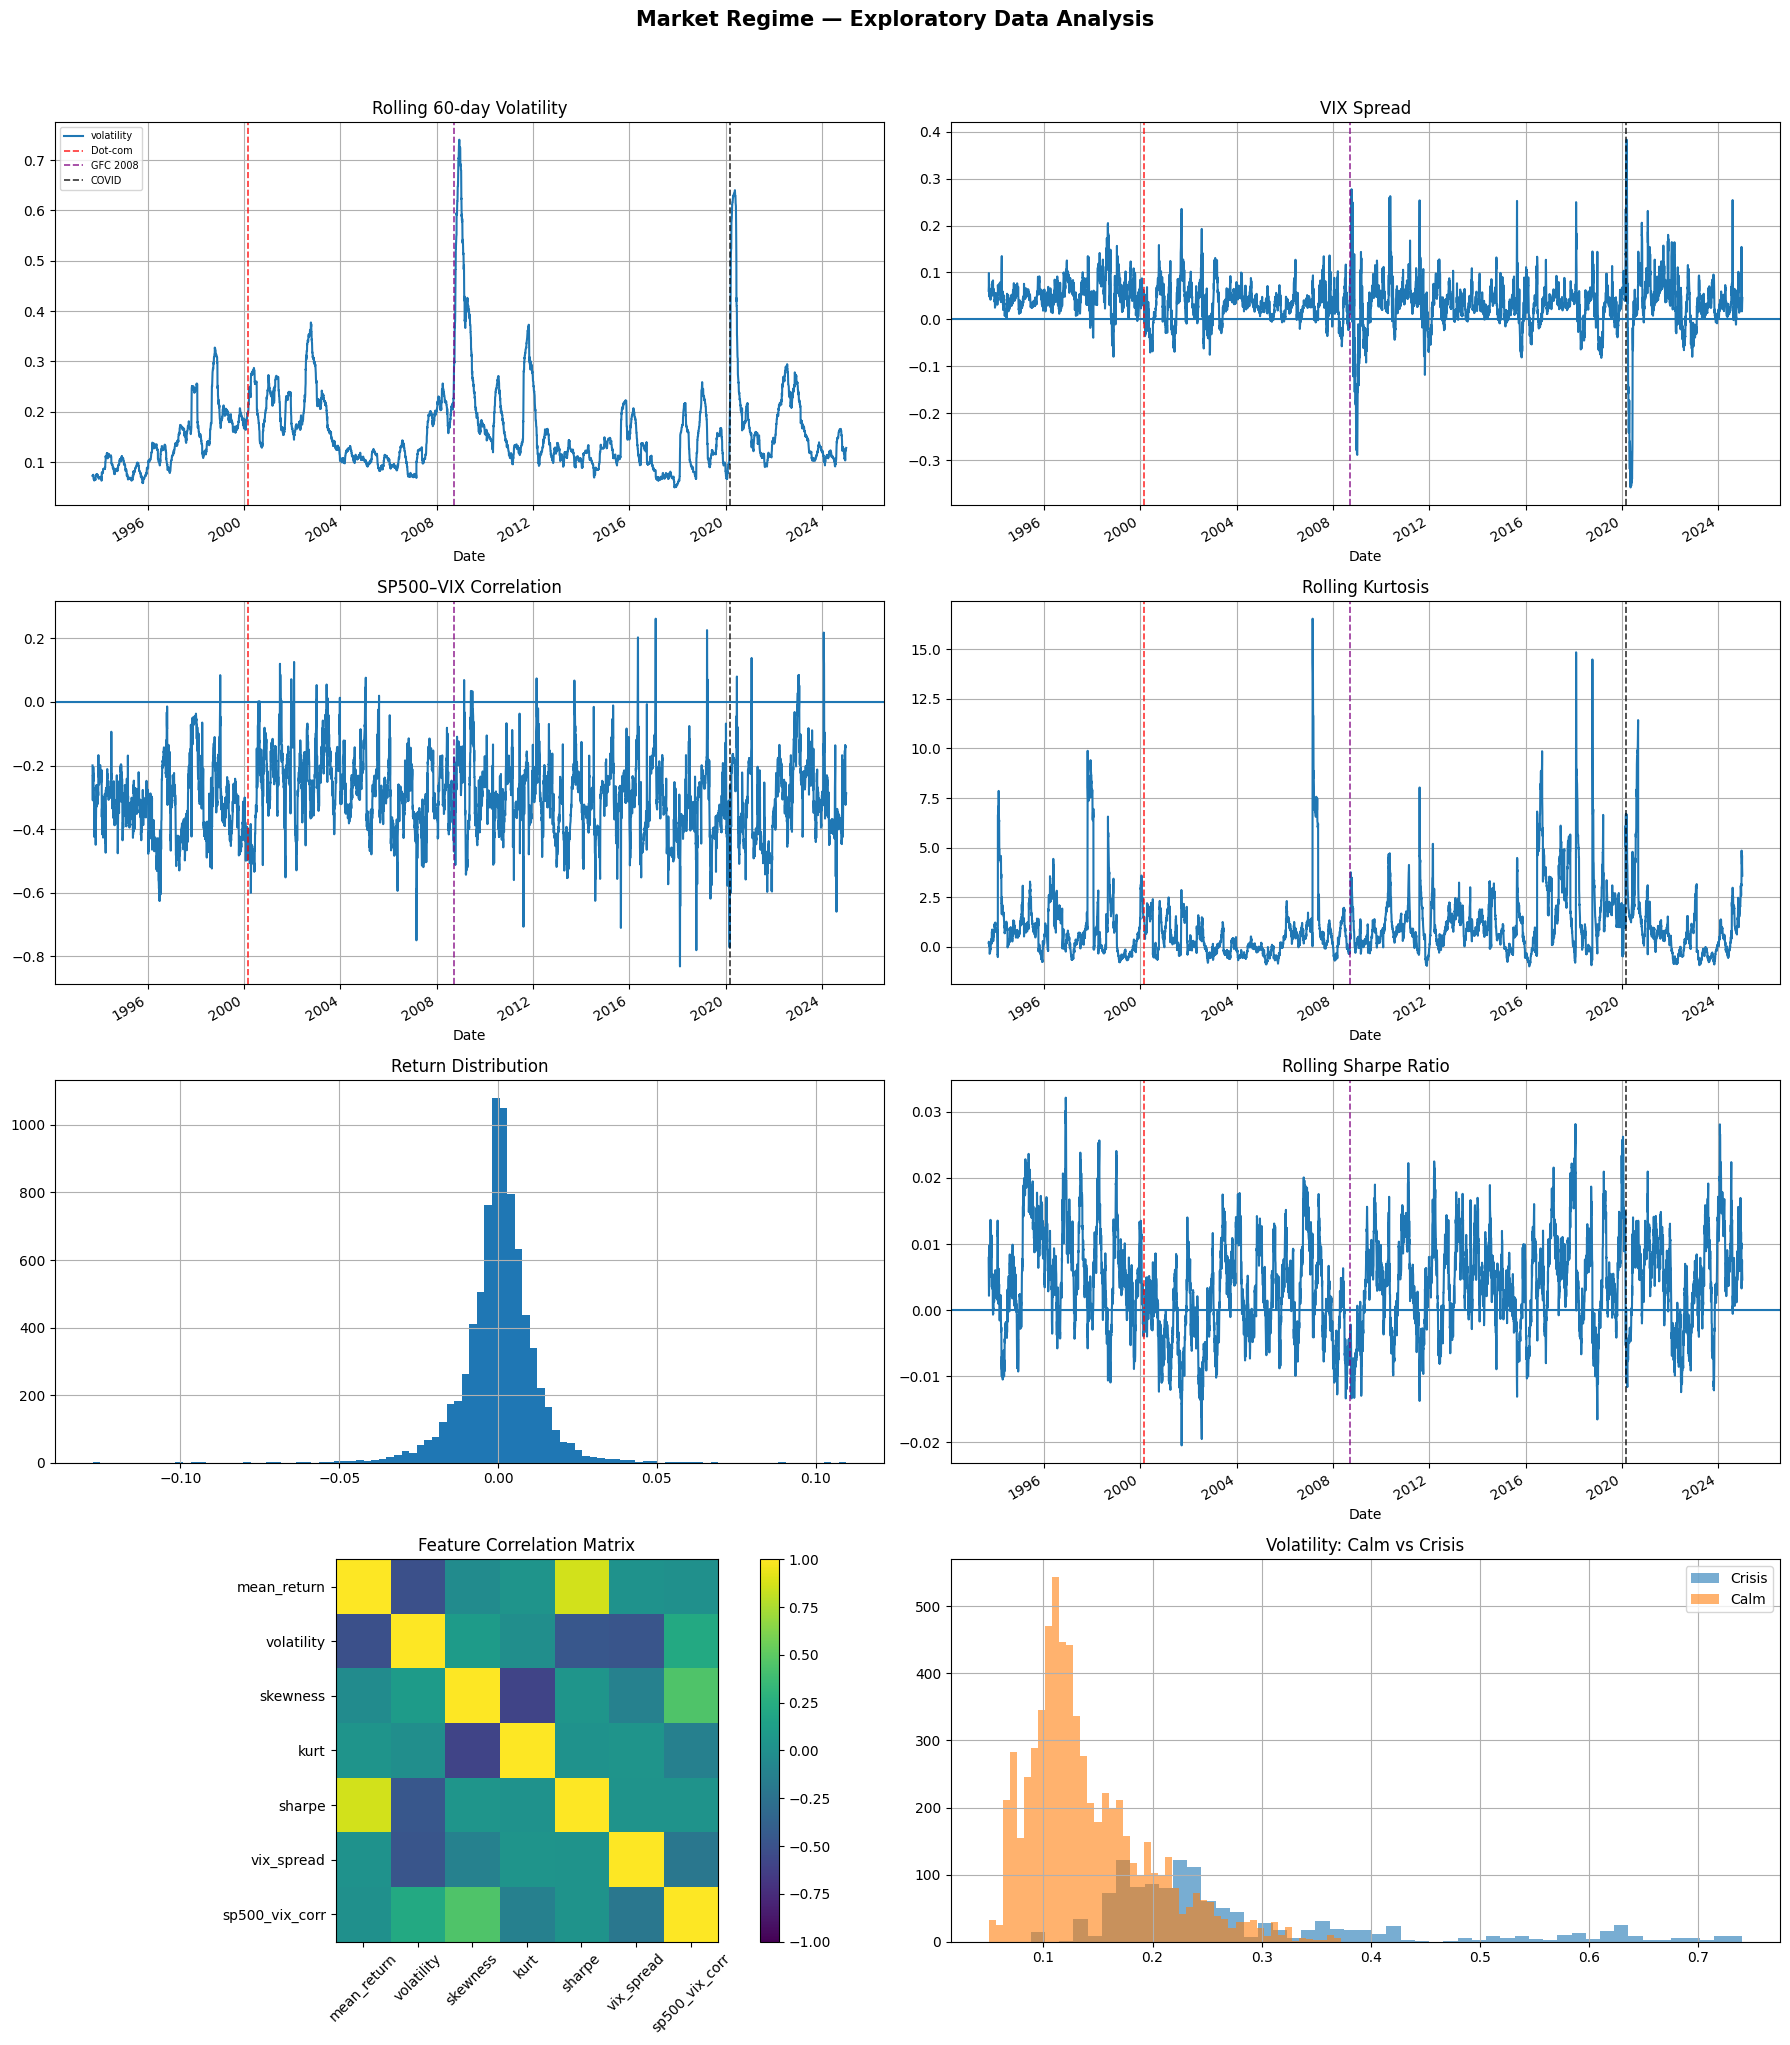

Saved: eda_full.png


In [39]:
# -------------------------------
# 2. EDA PLOTS
# -------------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle('Market Regime — Exploratory Data Analysis',
             fontsize=15, fontweight='bold', y=1.02)

# Crisis markers
crises = [
    ('2000-03-01', 'Dot-com',  'red'),
    ('2008-09-15', 'GFC 2008', 'purple'),
    ('2020-03-01', 'COVID',    'black')
]

def mark_crises(ax, show_legend=True):
    for date, label, color in crises:
        ax.axvline(pd.to_datetime(date), color=color,
                   linestyle='--', linewidth=1.2,
                   label=label, alpha=0.8)
    if show_legend:
        ax.legend(fontsize=7, loc='upper left')
# -------------------------------
# Plot 1 — Volatility
# -------------------------------
ax = axes[0, 0]
data['volatility'].plot(ax=ax)
mark_crises(ax)
ax.set_title('Rolling 60-day Volatility')
ax.grid(True)

# -------------------------------
# Plot 2 — VIX Spread
# -------------------------------
ax = axes[0, 1]
data['vix_spread'].plot(ax=ax)
mark_crises(ax, False)
ax.axhline(0)
ax.set_title('VIX Spread')
ax.grid(True)

# -------------------------------
# Plot 3 — Correlation
# -------------------------------
ax = axes[1, 0]
data['sp500_vix_corr'].plot(ax=ax)
mark_crises(ax, False)
ax.axhline(0)
ax.set_title('SP500–VIX Correlation')
ax.grid(True)

# -------------------------------
# Plot 4 — Kurtosis
# -------------------------------
ax = axes[1, 1]
data['kurt'].plot(ax=ax)
mark_crises(ax, False)
ax.set_title('Rolling Kurtosis')
ax.grid(True)

# -------------------------------
# Plot 5 — Return Distribution
# -------------------------------
ax = axes[2, 0]
data['sp500_return'].hist(ax=ax, bins=100)
ax.set_title('Return Distribution')
ax.grid(True)

# -------------------------------
# Plot 6 — Sharpe Ratio
# -------------------------------
ax = axes[2, 1]
data['sharpe'].plot(ax=ax)
mark_crises(ax, False)
ax.axhline(0)
ax.set_title('Rolling Sharpe Ratio')
ax.grid(True)

# -------------------------------
# Plot 7 — Correlation Heatmap
# -------------------------------
ax = axes[3, 0]
feature_cols = ['mean_return', 'volatility', 'skewness',
                'kurt', 'sharpe', 'vix_spread', 'sp500_vix_corr']

corr = data[feature_cols].corr()

im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45)
ax.set_yticklabels(feature_cols)
plt.colorbar(im, ax=ax)
ax.set_title('Feature Correlation Matrix')

# -------------------------------
# Plot 8 — Calm vs Crisis
# -------------------------------
ax = axes[3, 1]

crisis_mask = (
    ((data.index >= '2000-01-01') & (data.index <= '2002-12-01')) |
    ((data.index >= '2008-01-01') & (data.index <= '2009-06-01')) |
    ((data.index >= '2020-02-01') & (data.index <= '2020-09-01'))
)

data.loc[crisis_mask, 'volatility'].hist(ax=ax, bins=50, alpha=0.6, label='Crisis')
data.loc[~crisis_mask, 'volatility'].hist(ax=ax, bins=50, alpha=0.6, label='Calm')

ax.legend()
ax.set_title('Volatility: Calm vs Crisis')
ax.grid(True)

# -------------------------------
# Final Layout
# -------------------------------
plt.tight_layout()
plt.savefig('eda_full.png', dpi=150)
plt.show()

print("Saved: eda_full.png")

In [40]:
features_60 = compute_features(
    data['sp500_return'],
    data['vix_close'],
    window=60
)

features_60.to_csv("features_60d.csv")